In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [24]:
df = pd.read_csv("D:/Download/Synthetic (1).csv")
df.head()

,Unnamed: 0,X,Y
0,0,37.454012,126.746701
1,1,95.071431,293.927975
2,2,73.199394,225.441700
3,3,59.865848,183.586508
4,4,15.601864,39.020372


In [25]:
df.drop(columns=["Unnamed: 0"], inplace=True)
df.head()

,X,Y
0,37.454012,126.746701
1,95.071431,293.927975
2,73.199394,225.441700
3,59.865848,183.586508
4,15.601864,39.020372


In [26]:
x = df.iloc[:, 0].values
y = df.iloc[:, 1].values

# Standardize input feature
x = (x - np.mean(x)) / np.std(x)

# Keep x as a row vector and y as a column vector
x = x.reshape(1, -1)
y = y.reshape(-1, 1)

m = x.shape[1]

print("x shape:", x.shape)
print("y shape:", y.shape)
print("Number of samples:", m)

x shape: (1, 50)
y shape: (50, 1)
Number of samples: 50


In [27]:
epochs = 10000
learning_rate = 0.0001
tolerance = 0.0001

## 1. Batch Gradient Descent

In [28]:
# Separate initialization for Batch GD
theta_0_bgd = np.array(np.random.randn()).reshape(1, 1)
theta_1_bgd = np.array(np.random.randn()).reshape(1, 1)

epoch = 1
loss = np.inf
losses_bgd = []

while epoch <= epochs and loss > tolerance:

    # Prediction for all samples
    y_hat = theta_0_bgd + theta_1_bgd * x

    # Error shape: (m, 1)
    error = y_hat.T - y

    # Full-dataset loss
    loss = 0.5 * np.mean(error ** 2)

    # Full-batch gradients
    d_theta_0 = (1 / m) * np.sum(error)
    d_theta_1 = (1 / m) * np.dot(x, error)

    # Parameter updates
    theta_0_bgd = theta_0_bgd - learning_rate * d_theta_0
    theta_1_bgd = theta_1_bgd - learning_rate * d_theta_1

    losses_bgd.append(loss)
    epoch += 1

print("Batch GD epochs:", epoch - 1)
print("Final Batch GD loss:", loss)

Batch GD epochs: 10000
Final Batch GD loss: 1930.5686024348197


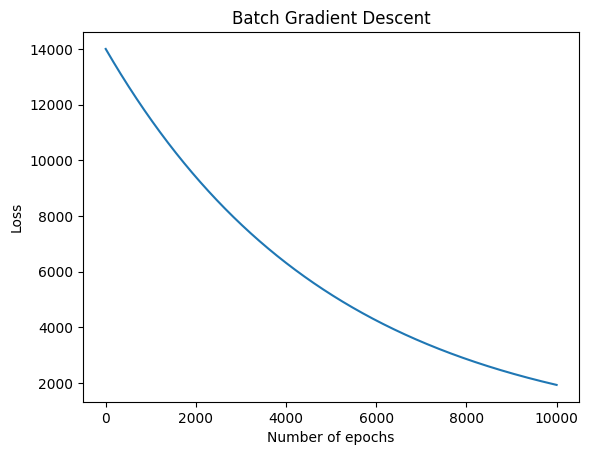

In [29]:
plt.figure()
plt.plot(losses_bgd)
plt.title("Batch Gradient Descent")
plt.xlabel("Number of epochs")
plt.ylabel("Loss")
plt.show()

## 2. Stochastic Gradient Descent (SGD)

In [30]:
# Separate initialization for SGD
theta_0_sgd = np.array(np.random.randn()).reshape(1, 1)
theta_1_sgd = np.array(np.random.randn()).reshape(1, 1)

epoch = 1
loss = np.inf
losses_sgd = []

while epoch <= epochs and loss > tolerance:

    epoch_losses = []

    for i in range(m):

        # Select one sample and preserve 2D shapes
        x_i = x[:, i:i+1]       # Shape: (1, 1)
        y_i = y[i:i+1, :]       # Shape: (1, 1)

        # Prediction
        y_hat = theta_0_sgd + theta_1_sgd * x_i

        # Error and sample loss
        error = y_hat.T - y_i
        sample_loss = 0.5 * np.mean(error ** 2)
        epoch_losses.append(sample_loss)

        # SGD gradients for one sample
        d_theta_0 = np.sum(error)
        d_theta_1 = np.dot(x_i, error)

        # Parameter updates after every sample
        theta_0_sgd = theta_0_sgd - learning_rate * d_theta_0
        theta_1_sgd = theta_1_sgd - learning_rate * d_theta_1

        # Store loss for every update
        losses_sgd.append(sample_loss)

    # Average loss over the complete epoch
    loss = np.mean(epoch_losses)
    epoch += 1

print("SGD epochs:", epoch - 1)
print("Final SGD epoch-average loss:", loss)

SGD epochs: 10000
Final SGD epoch-average loss: 41.16321857836933


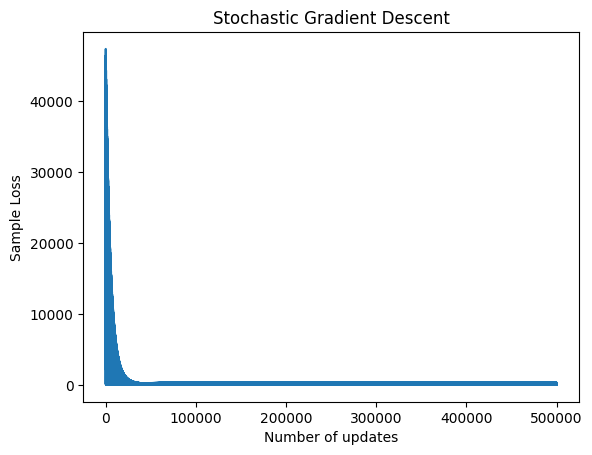

In [31]:
plt.figure()
plt.plot(losses_sgd)
plt.title("Stochastic Gradient Descent")
plt.xlabel("Number of updates")
plt.ylabel("Sample Loss")
plt.show()

## 3. Mini-batch Gradient Descent

In [21]:
# Separate initialization for Mini-batch GD
theta_0_mb = np.array(np.random.randn()).reshape(1, 1)
theta_1_mb = np.array(np.random.randn()).reshape(1, 1)

batch_size = 32
epoch = 1
loss = np.inf
losses_mb = []

while epoch <= epochs and loss > tolerance:

    epoch_losses = []

    for i in range(0, m, batch_size):

        # Select one mini-batch
        x_batch = x[:, i:i+batch_size]
        y_batch = y[i:i+batch_size, :]

        # Actual size of the current batch
        current_batch_size = x_batch.shape[1]

        # Prediction
        y_hat = theta_0_mb + theta_1_mb * x_batch

        # Error and batch loss
        error = y_hat.T - y_batch
        batch_loss = 0.5 * np.mean(error ** 2)
        epoch_losses.append(batch_loss)

        # Mini-batch gradients
        d_theta_0 = (1 / current_batch_size) * np.sum(error)
        d_theta_1 = (1 / current_batch_size) * np.dot(x_batch, error)

        # Parameter updates after every mini-batch
        theta_0_mb = theta_0_mb - learning_rate * d_theta_0
        theta_1_mb = theta_1_mb - learning_rate * d_theta_1

        # Store loss for every mini-batch update
        losses_mb.append(batch_loss)

    # Average loss over the complete epoch
    loss = np.mean(epoch_losses)
    epoch += 1

print("Mini-batch GD epochs:", epoch - 1)
print("Final mini-batch epoch-average loss:", loss)

Mini-batch GD epochs: 10000
Final mini-batch epoch-average loss: 272.19080665908814


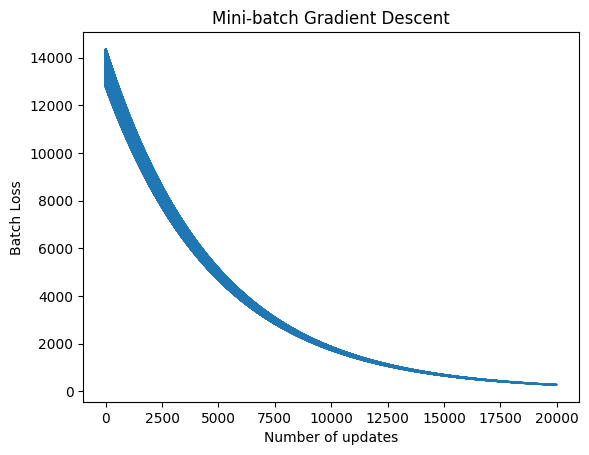

In [22]:
plt.figure()
plt.plot(losses_mb)
plt.title("Mini-batch Gradient Descent")
plt.xlabel("Number of updates")
plt.ylabel("Batch Loss")
plt.show()

## Important Notes

- Batch GD updates the parameters once per epoch.
- SGD updates the parameters after every single sample.
- Mini-batch GD updates the parameters after every mini-batch.
- Each algorithm uses separate initial values for `theta_0` and `theta_1`.
- The actual batch size is used for the final mini-batch if it contains fewer than 32 samples.
- SGD and Mini-batch GD plots use number of updates on the x-axis.